In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [5]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby(['Дата'])['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64

Нарисуйте график продаж у `grouped_df`

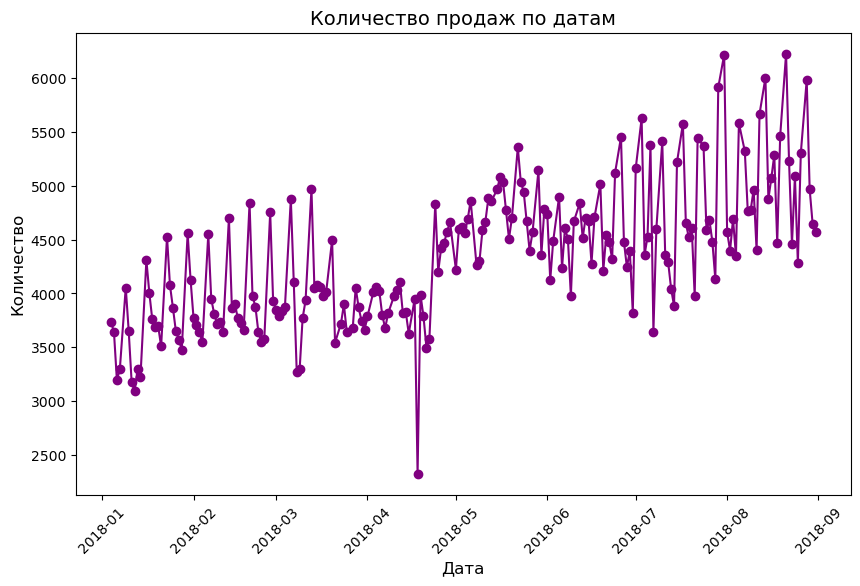

In [41]:
 
plt.figure(figsize=(10, 6))  # Исправлен размер
plt.plot(grouped_df.index, grouped_df.values, marker='o', linestyle='-', color='purple')
plt.title('Количество продаж по датам', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=45)

# Убираем tight_layout(), если он вызывает ошибку

plt.show()


Опишите что вы видите на графике. Ваша задача - максимально описать график

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [28]:
IQR = np.percentile(df['Количество'], 75) - np.percentile(df['Количество'], 25)
print(f'Межквартильный размах дл продукта: {IQR}')


Межквартильный размах дл продукта: 3.0


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [39]:
df['Дата'] = pd.to_datetime(df['Дата'], errors='coerce')
filtered_df = df[(df['Дата'].dt.month.isin([6, 7, 8])) & (df['Дата'].dt.weekday == 2) & (df['Склад'] == 3)]
grouped_df = filtered_df.groupby('Номенклатура')['Количество'].sum().reset_index()
top_product = grouped_df.loc[grouped_df['Количество'].idxmax()]
top_product

Номенклатура    product_1
Количество           2267
Name: 1, dtype: object

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [21]:
pip install pandas xlrd

In [27]:

import pandas as pd
a = "Astana.xls"
df1 = pd.read_excel(a, engine = 'xlrd', skiprows = 6)
df1.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,10.02.2025 11:00,-12.5,744.4,779.0,-0.3,94,"Ветер, дующий с юга",2,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",4,-13.3,NaN,NaN,NaN,NaN,NaN,NaN
1,10.02.2025 08:00,-15.2,744.7,779.8,0.0,95,"Ветер, дующий с юга",1,NaN,NaN,...,NaN,NaN,NaN,-15.8,NaN,NaN,NaN,NaN,Ровный слой сухого рассыпчатого снега покрывае...,45.0
2,10.02.2025 05:00,-15.4,744.7,779.8,0.3,82,"Ветер, дующий с юга",1,NaN,NaN,...,NaN,NaN,NaN,-17.8,NaN,NaN,NaN,NaN,NaN,NaN
3,10.02.2025 02:00,-15.1,744.4,779.5,0.0,80,"Штиль, безветрие",0,NaN,NaN,...,NaN,NaN,NaN,-17.8,NaN,NaN,NaN,NaN,NaN,NaN
4,09.02.2025 23:00,-14.5,744.4,779.4,0.4,79,"Штиль, безветрие",0,NaN,NaN,...,NaN,NaN,NaN,-17.3,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df1['Местное время в Астане'] = pd.to_datetime(df1['Местное время в Астане'],format ="%m.%d.%Y %H:%M", errors = 'coerce')


In [35]:
df1['Местное время в Астане'] = pd.to_datetime(df1['Местное время в Астане']).dt.date
mean_temp = df1.groupby(['Местное время в Астане'])['T'].mean()
mean_temp.head()

Местное время в Астане
2024-01-12   -12.1875
2024-02-12    -6.4250
2024-03-12    -6.3125
2024-04-12    -9.9375
2024-05-12    -5.1875
Name: T, dtype: float64

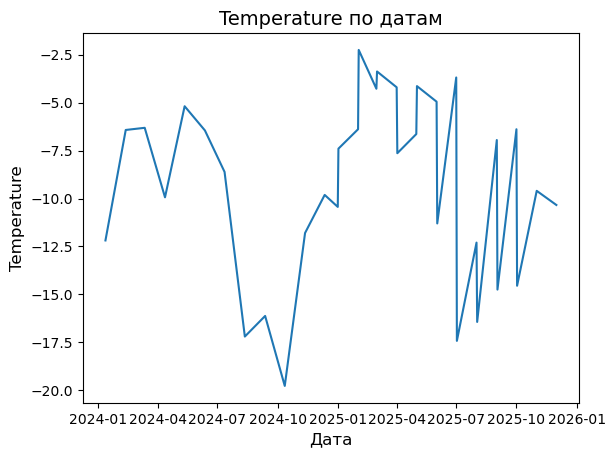

In [44]:

plt.plot(mean_temp.index, mean_temp.values)
plt.title('Temperature по датам', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Temperature', fontsize=12)
plt.show()